# Preprocessing — Pembersihan Teks & Split Dataset

Input: `data/processed/reviews_sampled.parquet` (6.990.280 baris, 18 kolom dari notebook 01).

Yang dilakukan di sini:
1. Bersihkan teks dari HTML tag, URL, dan whitespace berlebih
2. Analisis distribusi panjang token DistilBERT untuk menentukan `max_length`
3. Split stratified 70 / 15 / 15 → simpan ke `data/splits/`

**Tidak ada** stopword removal atau stemming — DistilBERT bekerja berdasarkan konteks kalimat penuh, jadi kata-kata 'biasa' tetap perlu ada.

## 0. Import Library

In [1]:
import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast

BASE_DIR   = r"D:\big-data-ai-sentiment"
PATH_PQ    = os.path.join(BASE_DIR, "data", "processed", "reviews_sampled.parquet")
PATH_SPLIT = os.path.join(BASE_DIR, "data", "splits")
PATH_FIG   = os.path.join(BASE_DIR, "outputs", "figures")

os.makedirs(PATH_SPLIT, exist_ok=True)

print("Import selesai.")

Import selesai.


## 1. Load Data

In [2]:
_pq_files = glob.glob(os.path.join(PATH_PQ, "part-*.parquet"))
if not _pq_files:
    raise FileNotFoundError(
        f"Parquet tidak ditemukan di {PATH_PQ}\n"
        "Jalankan Section 11 di notebook 01_spark_pipeline.ipynb terlebih dahulu."
    )

df = pd.read_parquet(PATH_PQ)
df['sentiment'] = pd.to_numeric(df['sentiment'], errors='coerce').astype(int)
df['stars']     = pd.to_numeric(df['stars'], errors='coerce')

# buang baris yang sentiment-nya tidak valid (harusnya 0)
n_before = len(df)
df = df[df['sentiment'].isin([0, 1, 2])].copy()
print(f"Baris dibuang (invalid) : {n_before - len(df)}")

print(f"Shape  : {df.shape}")
print(f"\nDistribusi sentimen:")
LABEL_MAP = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
for k, v in df['sentiment'].value_counts().sort_index().items():
    print(f"  {LABEL_MAP[k]:8s} ({k}) : {v:>7,}  ({v/len(df)*100:.1f}%)")

df[['review_id', 'text', 'sentiment', 'stars']].head(3)

Baris dibuang (invalid) : 0
Shape  : (6990280, 18)

Distribusi sentimen:
  Negatif  (0) : 1,613,801  (23.1%)
  Netral   (1) : 691,934  (9.9%)
  Positif  (2) : 4,684,545  (67.0%)


,review_id,text,sentiment,stars
0,FQLQXb-Hs-MlbIJf8eXUPw,Went for a nice lunch because prices in the Ga...,2,4.0
1,FoiFi2X684BwaYuYDnqBvw,It was okay. If you don't know anything about ...,1,3.0
2,G4YEeMu4Sj1XUEmlJwGe4A,Ate dinner there tonight. Service was pretty f...,2,4.0


## 2. Pembersihan Teks

Beberapa review Yelp mengandung HTML tag (`<br>`, `&amp;` dll) dan sesekali ada URL. Selain itu whitespace berlebih (newline ganda, tab) perlu dinormalisasi.

Tanda baca dan angka **tidak** dihapus karena DistilBERT memproses subword token dan bisa memanfaatkan informasi itu.

In [5]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)       # HTML tags
    text = re.sub(r'https?://\S+', ' ', text)  # URL
    text = re.sub(r'\s+', ' ', text).strip()   # whitespace berlebih
    return text.lower()

In [7]:
print("Membersihkan teks...")
df['text_clean'] = df['text'].apply(clean_text)

# lihat beberapa contoh sebelum/sesudah
print("\nContoh sebelum → sesudah:")
for i in [0, 1, 2]:
    before = df['text'].iloc[i][:150].replace('\n', ' ')
    after  = df['text_clean'].iloc[i][:150]
    print(f"  [{i+1}] BEFORE: {before}")
    print(f"       AFTER : {after}")
    print()

Membersihkan teks...

Contoh sebelum → sesudah:
  [1] BEFORE: Went for a nice lunch because prices in the Gaylord where I stayed aren't too friendly.   The service was excellent! Andrea was very friendly and atte
       AFTER : went for a nice lunch because prices in the gaylord where i stayed aren't too friendly. the service was excellent! andrea was very friendly and attent

  [2] BEFORE: It was okay. If you don't know anything about any blues history, it is well worth the visit.  It was almost all pictures and paragraphs on walls. Ther
       AFTER : it was okay. if you don't know anything about any blues history, it is well worth the visit. it was almost all pictures and paragraphs on walls. there

  [3] BEFORE: Ate dinner there tonight. Service was pretty fast and very nice. In fact, she might have tried a little hard to be nice and flirty.   I had the one-pi
       AFTER : ate dinner there tonight. service was pretty fast and very nice. in fact, she might have tried a little hard

In [8]:
df['len_before'] = df['text'].str.len()
df['len_after']  = df['text_clean'].str.len()

print("Statistik panjang karakter (sebelum vs sesudah cleaning):")
print(pd.DataFrame({
    'sebelum': df['len_before'].describe(),
    'sesudah': df['len_after'].describe()
}).round(1).to_string())

berubah = (df['text'] != df['text_clean']).sum()
print(f"\nTeks yang mengalami perubahan : {berubah:,} ({berubah/len(df)*100:.1f}%)")

kosong = (df['text_clean'].str.len() == 0).sum()
print(f"Teks kosong setelah cleaning  : {kosong}")
if kosong > 0:
    df = df[df['text_clean'].str.len() > 0].copy()
    print(f"Baris tersisa                 : {len(df):,}")

Statistik panjang karakter (sebelum vs sesudah cleaning):
         sebelum    sesudah
count  6990280.0  6990280.0
mean       567.8      564.8
std        527.3      524.0
min          1.0        0.0
25%        229.0      228.0
50%        406.0      404.0
75%        720.0      716.0
max       5000.0     5000.0

Teks yang mengalami perubahan : 6,966,331 (99.7%)
Teks kosong setelah cleaning  : 9
Baris tersisa                 : 6,990,271


## 3. Analisis Panjang Token DistilBERT

DistilBERT punya batas maksimum 512 token (termasuk `[CLS]` dan `[SEP]`). Review yang lebih panjang akan dipotong, jadi penting tahu berapa persen data yang ter-cover di tiap pilihan `max_length`.

Kita tokenisasi semua 6.99 juta baris pakai batch processing supaya hasilnya akurat (proses ini butuh waktu cukup lama karena ukuran data).

In [9]:
print("Memuat tokenizer distilbert-base-uncased...")
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print(f"Vocab size      : {tokenizer.vocab_size:,}")
print(f"Max pos embed   : {tokenizer.model_max_length}")

print(f"\nMenghitung panjang token untuk semua {len(df):,} baris (batch=512)...")
BATCH_SIZE  = 512
texts       = df['text_clean'].tolist()
all_lengths = []

for i in range(0, len(texts), BATCH_SIZE):
    batch   = texts[i : i + BATCH_SIZE]
    encoded = tokenizer(batch, add_special_tokens=True, truncation=False)
    all_lengths.extend(len(ids) for ids in encoded['input_ids'])
    if (i // BATCH_SIZE) % 100 == 0:
        print(f"  {i:>7,} / {len(texts):,} selesai...", end='\r')

token_lengths = pd.Series(all_lengths)
print(f"  {len(texts):>7,} / {len(texts):,} selesai.   ")

print("\nStatistik panjang token:")
print(token_lengths.describe().round(1).to_string())

Memuat tokenizer distilbert-base-uncased...
Vocab size      : 30,522
Max pos embed   : 512

Menghitung panjang token untuk semua 6,990,271 baris (batch=512)...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (623 > 512). Running this sequence through the model will result in indexing errors


  6,990,271 / 6,990,271 selesai.   

Statistik panjang token:
count    6990271.0
mean         132.6
std          121.7
min            3.0
25%           54.0
50%           95.0
75%          168.0
max         1601.0


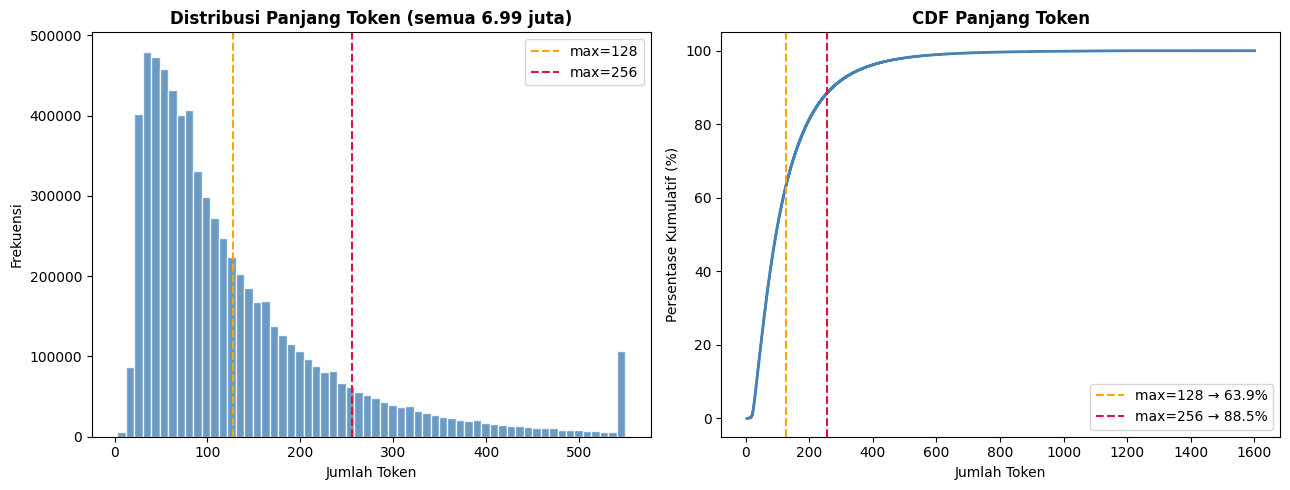

Gambar disimpan: 13_token_length_dist.png

Coverage per pilihan max_length:
  max_length= 64 :  32.1%  ██████
  max_length=128 :  63.9%  ████████████
  max_length=192 :  80.0%  ████████████████
  max_length=256 :  88.5%  █████████████████
  max_length=320 :  93.1%  ██████████████████
  max_length=512 :  98.2%  ███████████████████


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(token_lengths.clip(upper=550), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
for cutoff, color in [(128, 'orange'), (256, 'crimson')]:
    axes[0].axvline(cutoff, color=color, linestyle='--', linewidth=1.5, label=f'max={cutoff}')
axes[0].set_title('Distribusi Panjang Token (semua 6.99 juta)', fontweight='bold')
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

sorted_lens = np.sort(token_lengths.values)
cdf_vals    = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens) * 100
axes[1].plot(sorted_lens, cdf_vals, color='steelblue', linewidth=2)
for cutoff, color in [(128, 'orange'), (256, 'crimson')]:
    cov = (token_lengths <= cutoff).mean() * 100
    axes[1].axvline(cutoff, color=color, linestyle='--', linewidth=1.5,
                    label=f'max={cutoff} → {cov:.1f}%')
axes[1].set_title('CDF Panjang Token', fontweight='bold')
axes[1].set_xlabel('Jumlah Token')
axes[1].set_ylabel('Persentase Kumulatif (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_FIG, '13_token_length_dist.png'), bbox_inches='tight')
plt.show()
print("Gambar disimpan: 13_token_length_dist.png")

print("\nCoverage per pilihan max_length:")
for ml in [64, 128, 192, 256, 320, 512]:
    cov = (token_lengths <= ml).mean() * 100
    bar = '█' * int(cov / 5)
    print(f"  max_length={ml:>3d} : {cov:5.1f}%  {bar}")

## 4. Train / Val / Test Split

Split 70 / 15 / 15 dengan stratifikasi berdasarkan label sentimen — supaya proporsi Negatif/Netral/Positif sama di ketiga subset. Ini penting karena dataset imbalanced (~67% Positif).

Kolom yang disimpan: `review_id`, `text_clean`, `sentiment`, `stars`.

In [8]:
MAX_LENGTH = 512

cols     = ['review_id', 'text_clean', 'sentiment', 'stars']
df_model = df[cols].copy()

df_train, df_temp = train_test_split(
    df_model, test_size=0.30,
    stratify=df_model['sentiment'], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50,
    stratify=df_temp['sentiment'], random_state=42
)

print(f"Train : {len(df_train):,} baris ({len(df_train)/len(df_model)*100:.1f}%)")
print(f"Val   : {len(df_val):,} baris ({len(df_val)/len(df_model)*100:.1f}%)")
print(f"Test  : {len(df_test):,} baris ({len(df_test)/len(df_model)*100:.1f}%)")

print("\nDistribusi sentimen per split (harus konsisten):")
for name, dset in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    dist = dset['sentiment'].value_counts(normalize=True).sort_index() * 100
    parts = "  ".join([f"{LABEL_MAP[k]}: {v:.1f}%" for k, v in dist.items()])
    print(f"  {name:5s}: {parts}")

Train : 4,893,189 baris (70.0%)
Val   : 1,048,541 baris (15.0%)
Test  : 1,048,541 baris (15.0%)

Distribusi sentimen per split (harus konsisten):
  Train: Negatif: 23.1%  Netral: 9.9%  Positif: 67.0%
  Val  : Negatif: 23.1%  Netral: 9.9%  Positif: 67.0%
  Test : Negatif: 23.1%  Netral: 9.9%  Positif: 67.0%


In [9]:
df_train.to_csv(os.path.join(PATH_SPLIT, 'train.csv'), index=False)
df_val.to_csv(os.path.join(PATH_SPLIT, 'val.csv'),   index=False)
df_test.to_csv(os.path.join(PATH_SPLIT, 'test.csv'),  index=False)

print("File tersimpan:")
for fname in ['train.csv', 'val.csv', 'test.csv']:
    path = os.path.join(PATH_SPLIT, fname)
    size = os.path.getsize(path) / 1024**2
    print(f"  {fname:12s}: {size:.1f} MB")

File tersimpan:
  train.csv   : 2788.4 MB
  val.csv     : 597.6 MB
  test.csv    : 598.3 MB


## 5. Ringkasan

In [11]:
print("=" * 60)
print("RINGKASAN PREPROCESSING")
print("=" * 60)
print(f"\nDataset asal         : {len(df):,} baris")
print(f"Teks yang berubah    : {berubah:,} ({berubah/len(df)*100:.1f}%)")
print(f"max_length dipilih   : {MAX_LENGTH} token")
cov = (token_lengths <= MAX_LENGTH).mean() * 100
print(f"Coverage max_length  : {cov:.1f}% review tidak terpotong")
print(f"\nSplit 70/15/15 (stratified, seed=42):")
print(f"  train.csv : {len(df_train):,} baris")
print(f"  val.csv   : {len(df_val):,} baris")
print(f"  test.csv  : {len(df_test):,} baris")
print(f"\nDisimpan di: {PATH_SPLIT}")

RINGKASAN PREPROCESSING

Dataset asal         : 6,990,271 baris
Teks yang berubah    : 6,966,331 (99.7%)
max_length dipilih   : 512 token
Coverage max_length  : 98.2% review tidak terpotong

Split 70/15/15 (stratified, seed=42):
  train.csv : 4,893,189 baris
  val.csv   : 1,048,541 baris
  test.csv  : 1,048,541 baris

Disimpan di: D:\big-data-ai-sentiment\data\splits
